In [3]:
#1 Day-1 Study Case "Early Warning System for Sustainable Education"
import pandas as pd
import numpy as np

# Mengatur seed agar data yang dihasilkan konsisten
np.random.seed(42)

# Menentukan jumlah baris
n_rows = 100

# Membuat data dummy
data = {
  'Student_ID': [f'STU_{i:03d}' for i in range(1, n_rows + 1)],
  'Gender': np.random.choice ([0, 1], n_rows),
  'Parental_Support': np.random.randint(1, 6, n_rows),
  'GPA_Sem1': np.round(np.random.uniform (2.0, 4.0, n_rows), 2),
  'GPA_Sem2': np.round(np.random.uniform (1.8, 4.0, n_rows), 2),
  'Attendance_Rate': np.random.randint(60, 101, n_rows),
  'Financial_Stress': np.random.randint(1, 6, n_rows),
}

# Membuat logika sederhana untuk kolom Target (Dropout/Graduate)
# Misal: Jika GPA rendah dan kehadiran rendah, kemungkinan Dropout (0) lebih tinggi
df = pd.DataFrame (data)

def determine_target(row):
  score = (row['GPA_Sem1'] * 0.3) + (row['GPA_Sem2'] * 0.3) + (row['Attendance_Rate'])
  if score < 2.5 or row['GPA_Sem2'] < 2.0:
    return 0 # Dropout
  else:
    return 1 # Graduate

df['Target'] = df.apply(determine_target, axis=1)

#Menyimpan ke file CSV
df.to_csv('student_data.csv', index=False)

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

#1. Load Data (Karakteristik: Variety & Volume)
# Diasumsikan menggunakan dataset 'Predict Students Dropout and Academic Success'
df = pd.read_csv('student_data.csv')

#2. Preprocessing: Penentuan Fitur & Target
# Fitur: Nilai semester 1 & 2, GDP, biaya sekolah, dll.
x = df.drop(['Target', 'Student_ID'], axis=1) # Drop 'Student_ID' as it's not a feature
y = df ['Target'] # Label: 'Dropout', 'Enrolled', 'Graduate'

# Check for missing values
missing_parental_support = df ['Parental_Support'].isnull().sum()
print(f"Number of missing values in 'Parental_Support': {missing_parental_support}")

# If there were missing values, a heatmap could visualize their distribution
# plt.figure(figsize=(8,6))
# sns.heatmap(df[['Parental_Support']].isnull(), cbar=False, cmap='viridis')
# plt.title('Missing Values in Parental_Support (if any)')
# plt.show()

Number of missing values in 'Parental_Support': 0


Missing values in 'Parental_Support' after imputation: 0
Unique values and their counts in 'Parental_Support' after cleaning:
Parental_Support
1    24
2    15
3    19
4    22
5    20
Name: count, dtype: int64


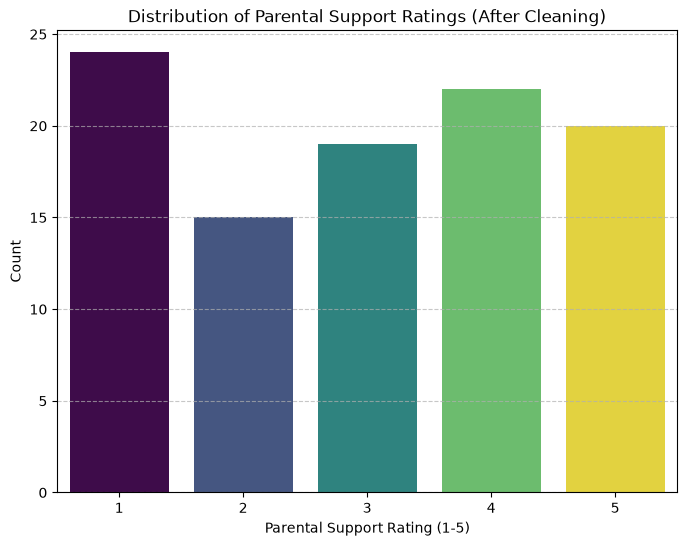

In [13]:
### Handling Missing and Inconsistent Data in 'Parental_Support'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 0.0 to NaN (as it's an inconsistent value outside the 1-5 range)
df ['Parental_Support'] = df ['Parental_Support'].replace(0.0, np.nan)

# Calculate the mode for 'Parental_Support'
parental_support_mode = df [ 'Parental_Support'].mode()[0]

# Impute missing values with the mode (addressing FutureWarning by not using inplace=True)
df['Parental_Support'] = df ['Parental_Support'].fillna (parental_support_mode)

print(f"Missing values in 'Parental_Support' after imputation: {df ['Parental_Support'].isnull().sum()}")
print(f"Unique values and their counts in 'Parental_Support' after cleaning:")
print(df['Parental_Support'].value_counts().sort_index())

# Update the plot to avoid FutureWarning
plt.figure(figsize=(8, 6))
sns.countplot(x='Parental_Support', data=df, hue='Parental_Support', palette='viridis', legend=False)
plt.title('Distribution of Parental Support Ratings (After Cleaning)')
plt.xlabel('Parental Support Rating (1-5)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [14]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.20,
    stratify=y,
    random_state=1
)

In [15]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=1
)

model.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

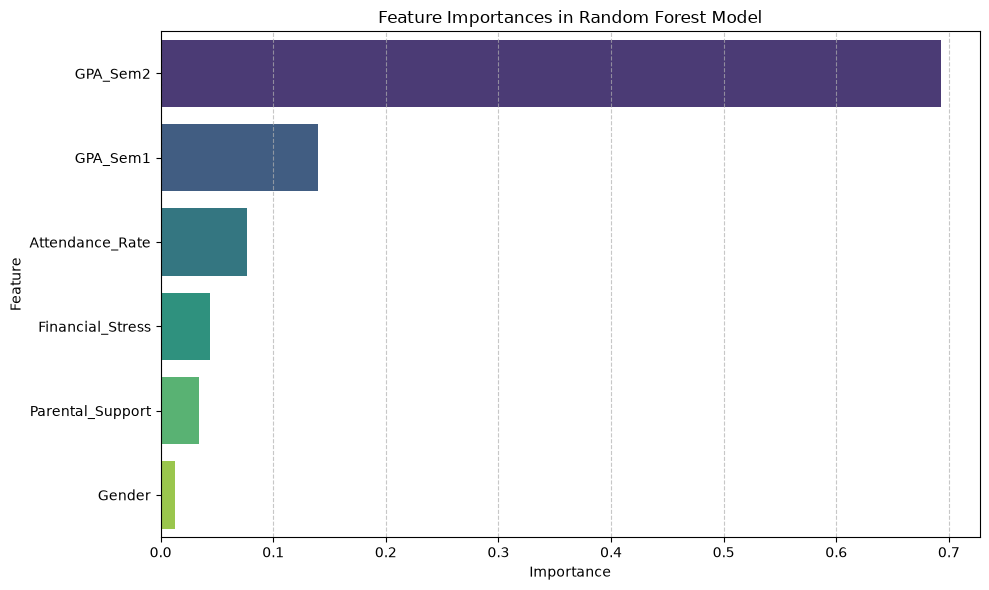

Top 5 most important features:
            Feature  Importance
3          GPA_Sem2    0.692980
2          GPA_Sem1    0.139910
4   Attendance_Rate    0.076982
5  Financial_Stress    0.043604
1  Parental_Support    0.033959


In [16]:
feature_importance = model.feature_importances_

features_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': feature_importance
})

features_df = features_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=features_df, hue='Feature', palette='viridis')
plt.title('Feature Importances in Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(features_df.head())